# Non-simultaneous Call Spread

This strategy involves entering into long and short positions on call options at different times.

Initially, call options with a strike price of $X_1$ were purchased. If the price of the underlying asset rises sufficiently, it becomes possible to sell call options with a strike price of $X_2$, where $X_2 < X_1$, at a higher price than was previously paid for the $X_1$ options. 

This implies that, in principle, the trade could no longer result in a loss.

The situation is illustrated in this notebook for Nvidia stock (ticker: NVDA) as follows.

Prior to January 16, 2023, 100 call options with a strike price of 165 were purchased at a cost of 7.50 per option. Since then, the stock price has risen to 168.99, and the premium for these options is now 12.65 per option.

On January 16, 2023, 100 call options with a strike price of 170 were sold at a price of 9.90 per option.

**Caveat: Options are very risky derivatives and, like any other type of financial vehicle, trading options requires due diligence. Transactions shown as examples of trading strategies with options in this notebook are not recommendations.**

In [1]:
from __future__ import print_function

import datetime as dt
import sys

from optionlab import __version__, run_strategy, plot_pl

%matplotlib inline

In [2]:
print(f"Python version: {sys.version}")
print(f"OptionLab version: {__version__}")

Python version: 3.11.9 | packaged by Anaconda, Inc. | (main, Apr 19 2024, 16:40:41) [MSC v.1916 64 bit (AMD64)]
OptionLab version: 1.9.0


In [3]:
stock_price = 168.99
volatility = 0.483
interest_rate = 0.045
min_stock = stock_price - 100.0
max_stock = stock_price + 100.0
start_date = "2023-01-16"
target_date = "2023-02-17"
model = "black-scholes"
strategy = [
    {
        "type": "call",
        "strike": 165.0,
        "premium": 12.65,
        "n": 100,
        "action": "buy",
        "prev_pos": 7.5,
    },
    {
        "type": "call",
        "strike": 170.0,
        "premium": 9.9,
        "n": 100,
        "action": "sell",
    },
]

inputs = {
    "stock_price": stock_price,
    "volatility": volatility,
    "start_date": start_date,
    "target_date": target_date,
    "interest_rate": interest_rate,
    "min_stock": min_stock,
    "max_stock": max_stock,
    "strategy": strategy,
}

In [4]:
%%time
out = run_strategy(inputs)

CPU times: total: 188 ms
Wall time: 228 ms


Profit/Loss diagram:
--------------------
The vertical green dashed line corresponds to the position of the stock's spot price. The right and left arrow markers indicate the strike prices of calls and puts, respectively, with blue representing long and red representing short positions.


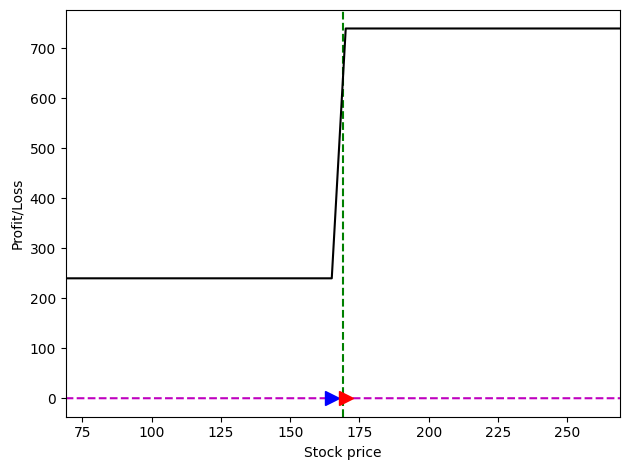

In [5]:
plot_pl(out)

In [6]:
print(out)

Probability of profit: 1.0
Profit ranges: [(0.0, inf)]
Expected profit if profitable: 492.76538500116345
Per leg cost: [-750.0, 990.0]
Strategy cost: 240.0
Minimum return in the domain: 240.0
Maximum return in the domain: 740.0000000000018
Implied volatility: [0.4942372292738575, 0.4826500896570693]
In the money probability: [0.54558925139931, 0.465831136209786]
Probability of touch: [1.0, 0.9661799112521838]
Delta: [0.6039490632362865, -0.525237550169406]
Gamma: [0.015297136732317718, 0.015806160944019643]
Theta: [-0.21821351060901806, 0.22301627833773927]
Vega: [0.20095091693287098, 0.20763771616023433]
Rho: [0.08536880237502183, -0.07509774107468528]

